<a href="https://colab.research.google.com/github/khairuladib94/dl-food-research/blob/main/session-6/notebooks/02_image_cnn_fruit_defect_tensorflow_keras.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Case Study 2: Fruit Defect Detection with a Keras CNN
Use `numpy` image arrays and a compact `Conv2D` network to classify synthetic fruit images as clean or defective.

<a href="https://colab.research.google.com/github/khairuladib94/dl-food-research/blob/main/session-6/notebooks/02_image_cnn_fruit_defect_tensorflow_keras.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open in Colab"/></a>

> **Colab workflow:** Save a copy in Drive, then choose Runtime > Run all. The required teaching dataset downloads automatically; Google Drive is not mounted.



## Learning route

Images preserve spatial neighbourhoods, so this notebook uses a 2D CNN rather than flattening every pixel at the start.

![Neural-network patterns for different food data](https://github.com/khairuladib94/dl-food-research/blob/main/session-6/assets/session6-network-patterns.png?raw=1)

The convolution filters scan small image regions, pooling reduces spatial size, and the final sigmoid returns the probability of a defect.


## 1. Prepare the notebook environment

We begin with the libraries used throughout the case study. Setting TensorFlow's log level before importing TensorFlow keeps the workshop output focused on the results.


In [6]:
from pathlib import Path
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers


### Make the data portable

The next cell first looks for `fruit_defect_images.npz` beside the notebook. If the file is absent—as it will be in a fresh Colab session—it downloads the public workshop copy. This keeps the notebook runnable without mounting Google Drive.


In [7]:
# Portable workshop data setup: local Jupyter first, Colab fallback.
DATA_FILE = 'fruit_defect_images.npz'
LOCAL_DATA_DIR = Path('../data')
if (LOCAL_DATA_DIR / DATA_FILE).exists():
    DATA_DIR = LOCAL_DATA_DIR
    IN_COLAB = False
else:
    from urllib.request import urlretrieve
    try:
        import google.colab  # type: ignore  # noqa: F401
        IN_COLAB = True
    except ImportError:
        IN_COLAB = False
    DATA_DIR = Path('/content/dl-food-research-data') if IN_COLAB else Path.cwd() / '.workshop-data'
    DATA_DIR.mkdir(parents=True, exist_ok=True)
    target = DATA_DIR / DATA_FILE
    if not target.exists():
        url = 'https://raw.githubusercontent.com/khairuladib94/dl-food-research/main' + '/session-6/data/' + DATA_FILE
        print(f'Downloading {DATA_FILE} ...')
        urlretrieve(url, target)
    print(f'Dataset ready: {target}')


Dataset ready: /content/dl-food-research-data/fruit_defect_images.npz


### Make the experiment repeatable

Fixed random seeds make the teaching run easier to reproduce. The helper functions also keep splitting, standardisation, and training-history summaries consistent across the five examples.

> **Important:** standardisation statistics are calculated from the training set only. Using the test set here would leak information into the model.


In [8]:
SEED = 7
np.random.seed(SEED)
tf.random.set_seed(SEED)

print('NumPy:', np.__version__)
print('Pandas:', pd.__version__)
print('TensorFlow:', tf.__version__)
print('Keras:', keras.__version__)

def make_split(n, test_fraction=0.2):
    idx = np.arange(n)
    np.random.shuffle(idx)
    cut = int(n * (1 - test_fraction))
    return idx[:cut], idx[cut:]

def standardize(train, test, axis=0):
    mean = train.mean(axis=axis, keepdims=True)
    std = train.std(axis=axis, keepdims=True) + 1e-8
    return (train - mean) / std, (test - mean) / std, mean, std

def history_table(history):
    hist = pd.DataFrame(history.history)
    return hist.tail(5).round(4)


NumPy: 2.0.2
Pandas: 2.2.2
TensorFlow: 2.20.0
Keras: 3.13.2


### Set up reusable plots

These helpers turn Keras histories and classification results into readable diagnostics. They do not affect training; they only help us inspect what the model learned.


In [9]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'figure.figsize': (8, 4.8),
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'font.size': 10
})

def plot_history(history, metrics=None, title='Training history'):
    hist = pd.DataFrame(history.history)
    metrics = metrics or [c for c in hist.columns if not c.startswith('val_')]
    fig, axes = plt.subplots(1, len(metrics), figsize=(6 * len(metrics), 4))
    if len(metrics) == 1:
        axes = [axes]
    for ax, metric in zip(axes, metrics):
        ax.plot(hist.index + 1, hist[metric], label=f'train {metric}', linewidth=2)
        val_metric = f'val_{metric}'
        if val_metric in hist:
            ax.plot(hist.index + 1, hist[val_metric], label=f'validation {metric}', linewidth=2)
        ax.set_xlabel('Epoch')
        ax.set_ylabel(metric)
        ax.set_title(metric)
        ax.legend()
    fig.suptitle(title, y=1.03, fontweight='bold')
    plt.tight_layout()
    plt.show()

def plot_binary_confusion(y_true, y_pred, labels, title='Confusion matrix'):
    cm = confusion_matrix(y_true.astype(int), y_pred.astype(int))
    disp = ConfusionMatrixDisplay(cm, display_labels=labels)
    fig, ax = plt.subplots(figsize=(4.8, 4.2))
    disp.plot(ax=ax, cmap='Blues', colorbar=False, values_format='d')
    ax.set_title(title)
    plt.tight_layout()
    plt.show()
    return cm


## 2. Load the image tensor

The array shape is `(samples, height, width, channels)`. Labels use `0` for clean fruit and `1` for defective fruit.


In [10]:
data = np.load(DATA_DIR / 'fruit_defect_images.npz')
images = data['images'].astype('float32')
labels = data['labels'].astype('float32')


### Create the held-out split

A separate test set estimates how well the CNN handles images it did not use for fitting.


In [11]:
train_idx, test_idx = make_split(len(images))
X_train, X_test = images[train_idx], images[test_idx]
y_train, y_test = labels[train_idx], labels[test_idx]

print('Image tensor:', X_train.shape)
pd.Series(y_train).value_counts().rename(index={0: 'clean', 1: 'defect'})


Image tensor: (416, 48, 48, 3)


,count
clean,210
defect,206


### Look at the images before modelling

Visual inspection can expose artifacts, unrealistic cues, and class imbalance that a summary table cannot show.


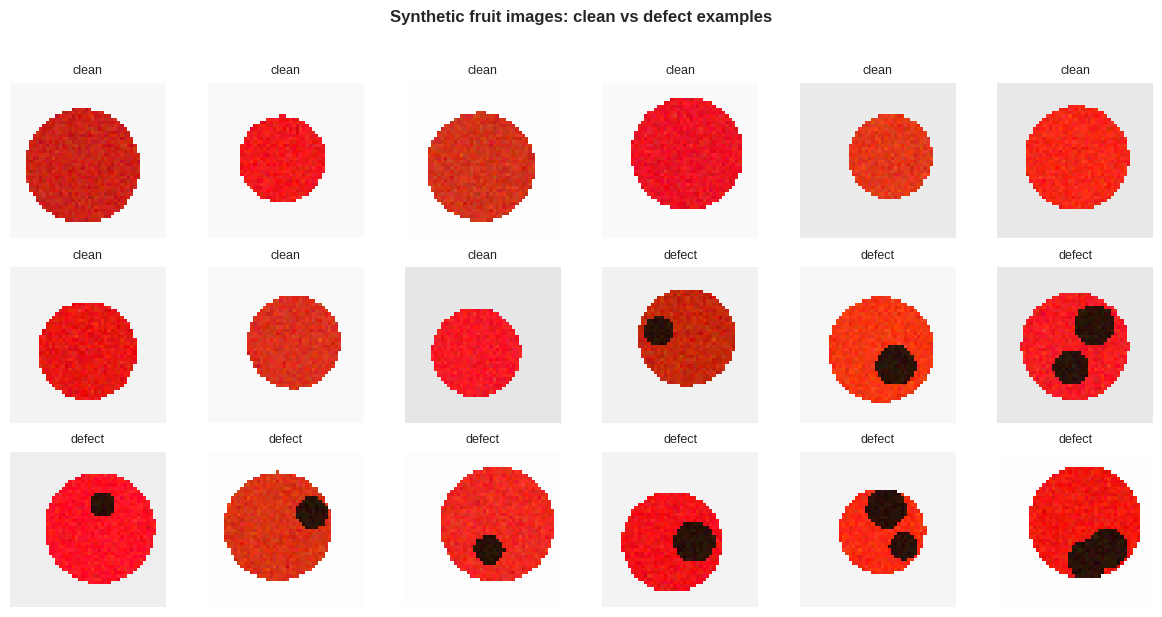

In [12]:
fig, axes = plt.subplots(3, 6, figsize=(12, 6))
sample_idx = np.r_[np.where(labels == 0)[0][:9], np.where(labels == 1)[0][:9]]
for ax, idx in zip(axes.ravel(), sample_idx):
    ax.imshow(images[idx])
    ax.set_title('defect' if labels[idx] else 'clean', fontsize=9)
    ax.axis('off')
fig.suptitle('Synthetic fruit images: clean vs defect examples', y=1.02, fontweight='bold')
plt.tight_layout()
plt.show()


### Check training class balance

A strongly imbalanced training set can make accuracy misleading and may require class weights or resampling.


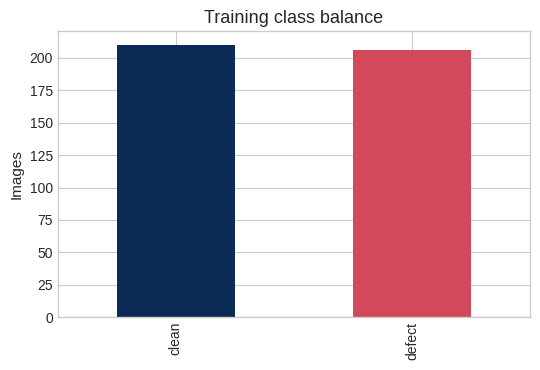

In [13]:
fig, ax = plt.subplots(figsize=(5.5, 3.8))
pd.Series(y_train).map({0: 'clean', 1: 'defect'}).value_counts().plot(kind='bar', ax=ax, color=['#0B2A55', '#D1495B'])
ax.set_title('Training class balance')
ax.set_xlabel('')
ax.set_ylabel('Images')
plt.tight_layout()
plt.show()


## 3. Build efficient input pipelines

`tf.data` batches the arrays and prefetches work. Only the training dataset is shuffled.


In [14]:
train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train))
train_ds = train_ds.shuffle(512, seed=SEED).batch(32).prefetch(tf.data.AUTOTUNE)


### Prepare the test pipeline

The test order stays fixed so evaluation remains deterministic and easy to inspect.


In [15]:
test_ds = tf.data.Dataset.from_tensor_slices((X_test, y_test)).batch(32).prefetch(tf.data.AUTOTUNE)


## 4. Build the 2D CNN

Repeated convolution and pooling layers learn local texture and shape patterns at progressively larger scales.


In [16]:
model = keras.Sequential([
    layers.Input(shape=X_train.shape[1:]),
    layers.Conv2D(16, 3, activation='relu', padding='same'),
    layers.MaxPooling2D(),
    layers.Conv2D(32, 3, activation='relu', padding='same'),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation='relu', padding='same'),
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.20),
    layers.Dense(1, activation='sigmoid')
])


### Configure binary classification

Binary cross-entropy matches a sigmoid output and a two-class target.


In [17]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=[keras.metrics.BinaryAccuracy(name='accuracy')]
)
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 48, 48, 16)     │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 24, 24, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 24, 24, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,649 (92.38 KB)

 Trainable params: 23,649 (92.38 KB)

 Non-trainable params: 0 (0.00 B)

## 5. Train and monitor

Validation on the held-out dataset gives an immediate—but optimistic if repeatedly tuned—view of generalisation.


In [18]:
history = model.fit(train_ds, validation_data=test_ds, epochs=10, verbose=0)
history_table(history)


,accuracy,loss,val_accuracy,val_loss
5,0.8053,0.5620,0.7981,0.5190
6,0.8269,0.4847,0.9423,0.4010
7,0.9255,0.3762,1.0000,0.2779
8,0.9543,0.2589,1.0000,0.1841
9,0.9784,0.1623,1.0000,0.1131


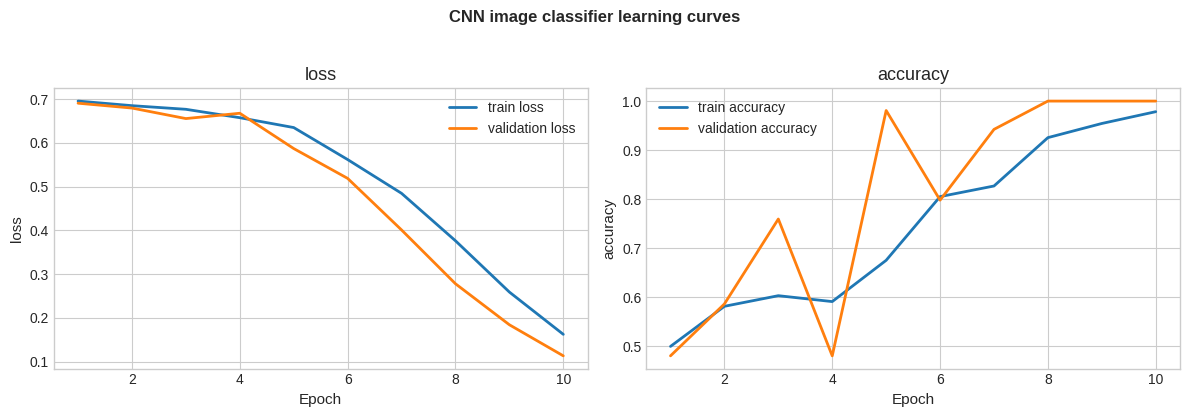

In [19]:
plot_history(history, metrics=['loss', 'accuracy'], title='CNN image classifier learning curves')


## 6. Evaluate probabilities

Accuracy gives one summary; probabilities show confidence and support threshold changes.


In [20]:
loss, acc = model.evaluate(test_ds, verbose=0)
prob = model.predict(X_test[:12], verbose=0).ravel()
print(f'Test accuracy: {acc:.3f}')


Test accuracy: 1.000


### Inspect sample decisions

Comparing true labels, probabilities, and thresholded predictions makes the decision rule explicit.


In [21]:
pd.DataFrame({
    'true_defect': y_test[:12].astype(int),
    'prob_defect': prob,
    'predicted_defect': (prob >= 0.5).astype(int)
}).round(3)


,true_defect,prob_defect,predicted_defect
0,1,0.728,1
1,1,0.988,1
2,1,0.778,1
3,1,0.994,1
4,0,0.078,0
5,1,0.918,1
6,0,0.065,0
7,1,0.985,1
8,0,0.129,0
9,0,0.072,0


### Find error patterns

A confusion matrix separates false alarms from missed defects; image thumbnails help diagnose the visual conditions behind those errors.


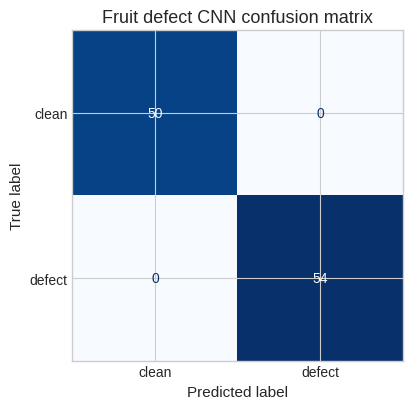

array([[50,  0],
       [ 0, 54]])

In [22]:
prob_full = model.predict(X_test, verbose=0).ravel()
pred_full = (prob_full >= 0.5).astype(int)
plot_binary_confusion(y_test, pred_full, labels=['clean', 'defect'], title='Fruit defect CNN confusion matrix')


### Review held-out images

Never stop at a single score. Look for lighting, position, or background patterns that the model may be exploiting.


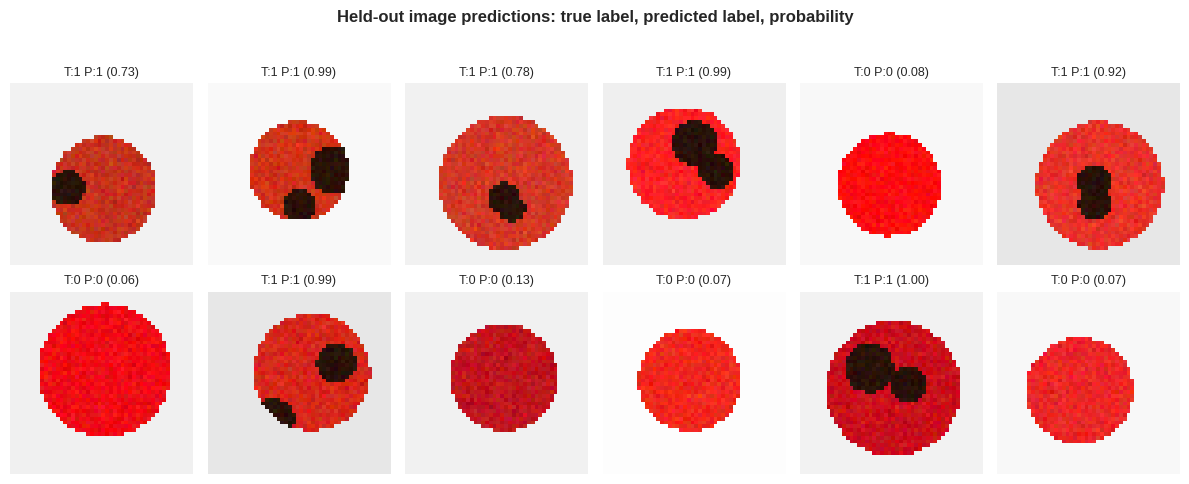

In [23]:
fig, axes = plt.subplots(2, 6, figsize=(12, 4.8))
for ax, img, true, prob_i, pred in zip(axes.ravel(), X_test[:12], y_test[:12], prob_full[:12], pred_full[:12]):
    ax.imshow(img)
    ax.set_title(f"T:{int(true)} P:{pred} ({prob_i:.2f})", fontsize=9)
    ax.axis('off')
fig.suptitle('Held-out image predictions: true label, predicted label, probability', y=1.03, fontweight='bold')
plt.tight_layout()
plt.show()


## How to read the evidence

![Three complementary views of model quality](https://github.com/khairuladib94/dl-food-research/blob/main/session-6/assets/session6-evaluation-views.png?raw=1)

Learning curves describe optimization, predictions show sample-level behaviour, and error summaries expose the kinds of mistakes being made. A publishable conclusion needs all three, plus external validation that matches the intended use.


## Teaching notes
- In real fruit imaging, lighting and background can become shortcuts.
- Validate on images from a different day, camera position, or supplier.
- For localisation, extend this idea to segmentation instead of only classification.